# Capítulo 4 — Avaliação: Métricas e Comparação entre Cenários
Calculamos as métricas de classificação para cada algoritmo em cada cenário,
exibimos matrizes de confusão e produzimos a tabela comparativa central do trabalho.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path
from reconciliacao.utils.config import load_config
from reconciliacao.models.features import build_features
from reconciliacao.models.trainer import train_all
from reconciliacao.models.evaluator import evaluate_all

cfg = load_config("../config.yaml")
all_metrics = []

for scenario in ["exact", "fuzzy"]:
    df = pd.read_csv(f"../data/processed/{scenario}_reconciliado.csv")
    X, y = build_features(df)
    results = train_all(X, y, cfg, Path(f"../data/results/{scenario}/models"))
    scfg = cfg["scenarios"][scenario]
    metrics = evaluate_all(results, scfg["n_classes"], Path(f"../data/results/{scenario}"))
    metrics["scenario"] = scenario
    all_metrics.append(metrics.reset_index())

summary = pd.concat(all_metrics).set_index(["scenario", "algorithm"])
print(summary[["accuracy", "f1_macro", "precision_macro", "recall_macro", "cv_mean"]].to_string())

                              accuracy  f1_macro  precision_macro  recall_macro   cv_mean
scenario algorithm                                                                       
exact    random_forest        1.000000  1.000000         1.000000      1.000000  1.000000
         svm                  0.913564  0.887304         0.944915      0.856828  0.907961
         logistic_regression  0.913564  0.887304         0.944915      0.856828  0.908580
fuzzy    random_forest        1.000000  1.000000         1.000000      1.000000  0.999633
         svm                  0.920878  0.864478         0.956706      0.827956  0.863620
         logistic_regression  0.923537  0.868358         0.965898      0.830383  0.870051


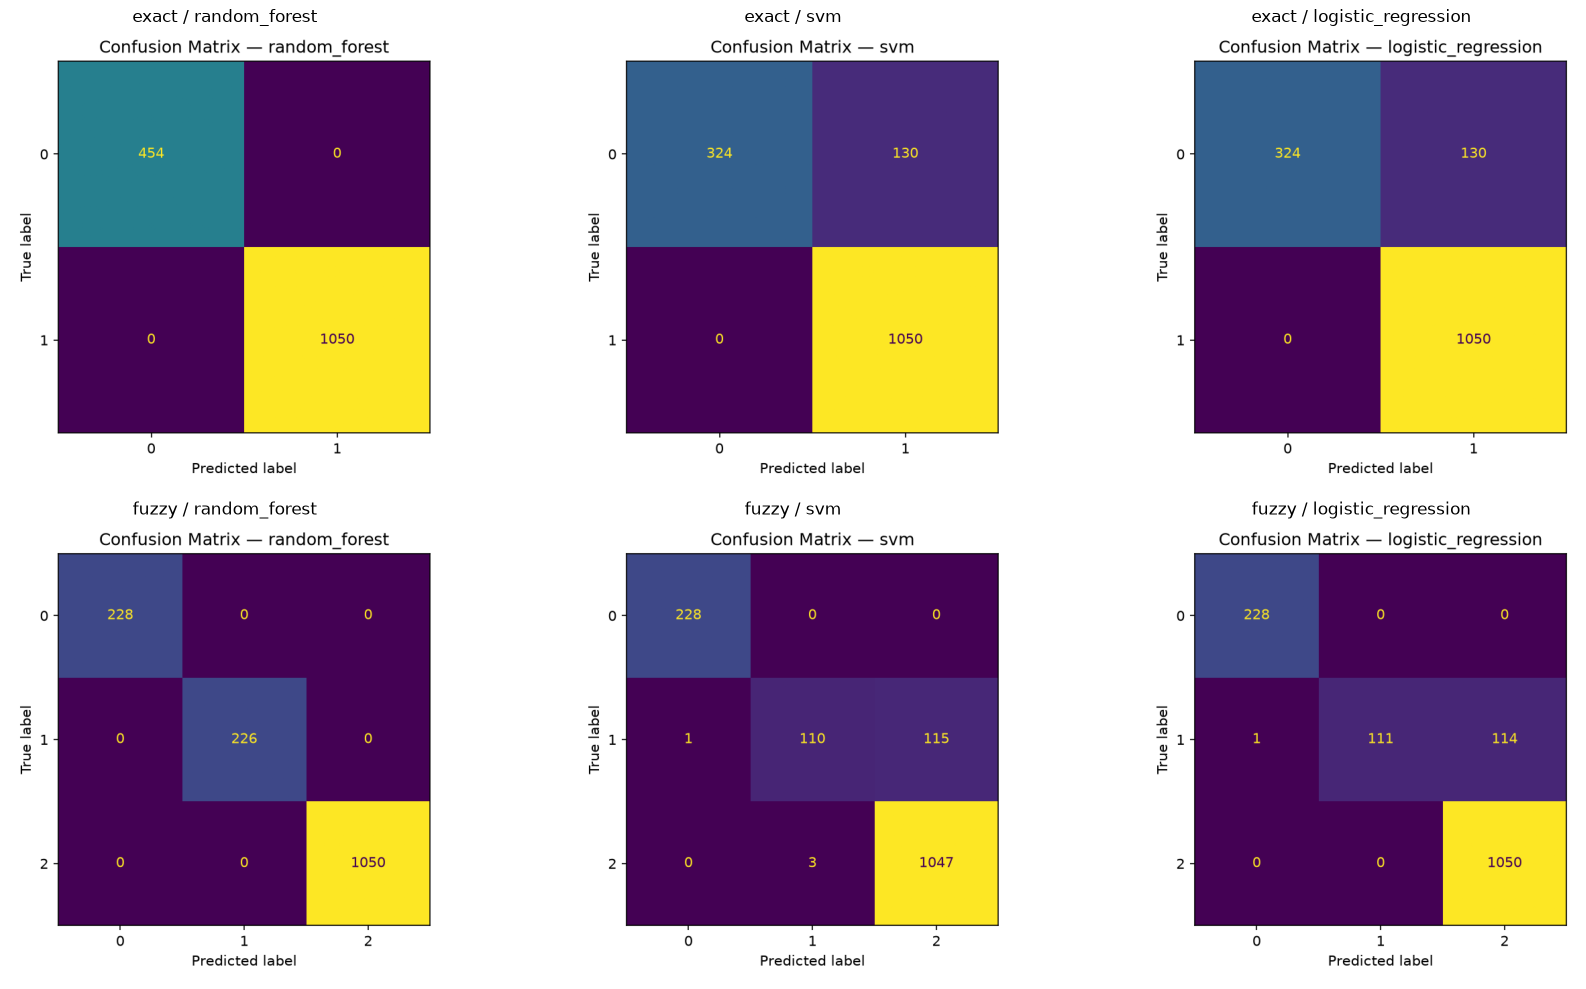

In [2]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
algorithms = ["random_forest", "svm", "logistic_regression"]
for row_idx, scenario in enumerate(["exact", "fuzzy"]):
    for col_idx, alg in enumerate(algorithms):
        img_path = Path(f"../data/results/{scenario}/confusion_matrix_{alg}.png")
        if img_path.exists():
            axes[row_idx][col_idx].imshow(mpimg.imread(str(img_path)))
            axes[row_idx][col_idx].axis("off")
            axes[row_idx][col_idx].set_title(f"{scenario} / {alg}")
plt.tight_layout()
plt.show()